# Landslide experiments — restart-safe runner

This notebook is a thin front-end for `landslide_utils.py`. All definitions (data, models, training) live in that file, and every experiment saves itself to disk, so **closing the laptop no longer loses anything**.

**After any restart: run the notebook from the top (Run All).**
- Finished experiments are loaded from `results/*.csv` in seconds, with no retraining.
- An experiment that was interrupted resumes from its last finished epoch.
- Changing an experiment's settings (same tag) retrains it; use `force=True` to retrain on purpose.

Folder layout created next to this notebook:
```text
results/       per-epoch history (.csv), run summary (.json), efficiency_benchmark.csv
checkpoints/   <run>_best.pth (best val F1), <run>_last.pt (resume state, removed when the run finishes)
```
Keep `landslide_utils.py` in the same folder as this notebook.

## 0 · Setup (run after every restart)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from landslide_utils import *          # data, models, training, caching, benchmark

# DATA_ROOT defaults to ./data  (needs Train.csv and train_data/). Edit here if yours differs:
# import landslide_utils; landslide_utils.DATA_ROOT = Path(r"D:\landslide\data")

device = get_device()
print("Device:", device)
data = load_data()                      # same stratified 80/20 split, random_state=42

Device: cuda
Train 5717 | Val 1430 | pos_weight 4.6942


## 1 · Recover your earlier results (run once)
The history variables from E1–E6 were lost when the kernel restarted, but the **best checkpoints** are still on disk. This cell copies them into `checkpoints/` and re-evaluates them on the validation set (no training). Skip it if you do not need it.

`KNOWN_RESULTS` holds the numbers recorded from your earlier notebook outputs, so the comparison tables can always be rebuilt.

In [4]:
# Point `src` to the folder where the old *_best.pth files are (the folder you ran the old notebook from)
migrate_legacy_checkpoints(src=".", move=False)
display(recover_legacy_metrics(data).round(4))

multimodal_mobilenet_v3_small_best.pth  ->  checkpoints/E3_random_seed42_best.pth
e4_pretrained_multimodal_best.pth  ->  checkpoints/E4_original_seed42_best.pth
e5a_ndvi_best.pth  ->  checkpoints/E5a_ndvi_seed42_best.pth
e5b_ndvi_ndwi_best.pth  ->  checkpoints/E5b_ndvi_ndwi_seed42_best.pth
E4_rerun_seed42_best.pth  ->  checkpoints/E4_rerun_seed42_best.pth
E6a_aug_seed42_best.pth  ->  checkpoints/E6a_aug_seed42_best.pth
E6b_cos_seed42_best.pth  ->  checkpoints/E6b_cos_seed42_best.pth
E6c_cos_lowlr_seed42_best.pth  ->  checkpoints/E6c_cos_lowlr_seed42_best.pth


,val_f1,val_auc,precision,recall
run,,,,
E3_random,0.6520,0.8977,0.5660,0.7689
E4_original,0.7742,0.9573,0.7391,0.8127
E5a_ndvi,0.7641,0.9539,0.6845,0.8645
E5b_ndvi_ndwi,0.7632,0.9574,0.7224,0.8088
E4_rerun,0.7815,0.9566,0.7301,0.8406
E6a_aug,0.8092,0.9680,0.7766,0.8446
E6b_cos,0.7945,0.9598,0.7808,0.8088
E6c_cos_lowlr,0.7154,0.9313,0.6914,0.7410


In [5]:
display(KNOWN_RESULTS)

,best_val_f1,last5_mean_f1,last5_std,auc,note
run,,,,,
E1 S2-only,0.5714,NaN,NaN,NaN,"random init, 1.00 M"
E2 S1-only,0.5416,NaN,NaN,NaN,"random init, 1.00 M"
E3 late fusion,0.6288,NaN,NaN,NaN,"random init, 2.00 M"
E4 pretrained,0.7742,NaN,NaN,0.9573,"ImageNet init, 2.00 M"
E5a +NDVI,0.7641,NaN,NaN,0.9539,no gain vs E4
E5b +NDVI+NDWI,0.7632,NaN,NaN,0.9574,no gain vs E4
E4 re-run,0.7815,0.7386,0.0385,0.9566,E6 baseline
E6a augmentation,0.8092,0.7723,0.0298,0.9680,flips + rot90
E6b warmup+cosine,0.7945,0.7875,0.0071,0.9598,peak lr 1e-3


## 2 · E6 — augmentation and training schedule (with caching)
Add or change entries in `CONFIGS` and re-run. Runs that already exist on disk are skipped.

| Run | Augmentation | LR schedule | Peak LR |
|---|---|---|---|
| `E4_rerun` | none | constant | 1e-3 |
| `E6a_aug` | flips + 90° rotations | constant | 1e-3 |
| `E6b_cos` | none | warmup + cosine | 1e-3 |
| `E6c_cos_lowlr` | none | warmup + cosine | 3e-4 |
| `E6d_aug_cos` | flips + 90° rotations | warmup + cosine | 1e-3 |

Set `SEEDS = [42, 1, 2]` for a more reliable comparison. Each seed is cached separately, so adding seeds only trains the new ones.

In [6]:
SEEDS = [42]            # -> [42, 1, 2] for a noise-robust comparison

CONFIGS = {
    "E4_rerun":      dict(aug=False, sched="const",  lr=1e-3),
    "E6a_aug":       dict(aug=True,  sched="const",  lr=1e-3),
    "E6b_cos":       dict(aug=False, sched="cosine", lr=1e-3),
    "E6c_cos_lowlr": dict(aug=False, sched="cosine", lr=3e-4),
    "E6d_aug_cos":   dict(aug=True,  sched="cosine", lr=1e-3),
}

e6_results = run_grid(data, CONFIGS, seeds=SEEDS)

[cached] E4_rerun_seed42: loaded from disk (best val F1 = 0.7646 @ epoch 15)
[cached] E6a_aug_seed42: loaded from disk (best val F1 = 0.7920 @ epoch 15)
[cached] E6b_cos_seed42: loaded from disk (best val F1 = 0.7992 @ epoch 9)
[cached] E6c_cos_lowlr_seed42: loaded from disk (best val F1 = 0.7444 @ epoch 7)
[cached] E6d_aug_cos_seed42: loaded from disk (best val F1 = 0.8172 @ epoch 15)


,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E4_rerun,0.7646,NaN,0.7409,0.0195,0.9410,15.0,1
E6a_aug,0.7920,NaN,0.7426,0.0643,0.9637,15.0,1
E6b_cos,0.7992,NaN,0.7864,0.0034,0.9643,9.0,1
E6c_cos_lowlr,0.7444,NaN,0.7208,0.0043,0.9393,7.0,1
E6d_aug_cos,0.8172,NaN,0.8106,0.0047,0.9746,15.0,1


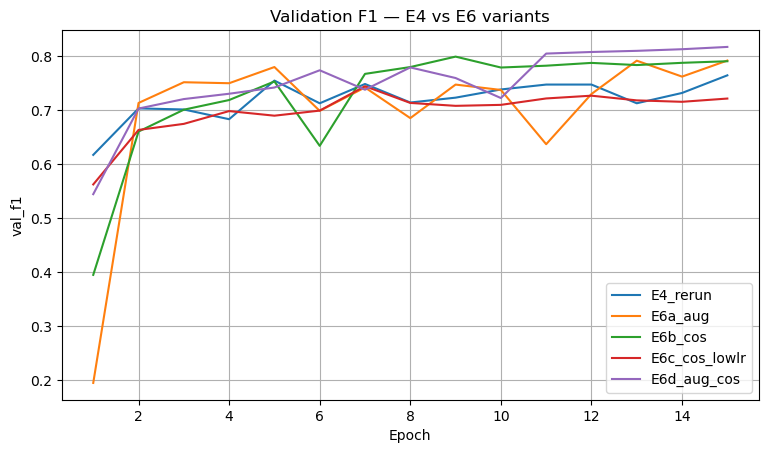

In [7]:
summary = summarize_runs(e6_results)
display(summary.round(4))
plot_curves(e6_results, "val_f1", "Validation F1 — E4 vs E6 variants")

## 3 · Adding a new experiment (template)
Any new experiment is one more entry. Example for the next steps in the roadmap:

```python
NEW = {
    "E7_example": dict(aug=True, sched="cosine", lr=1e-3, indices=("ndvi",)),
}
new_results = run_grid(data, NEW, seeds=[42])
display(summarize_runs({**e6_results, **new_results}).round(4))
```

Arguments of `run_experiment` / `run_grid`: `aug`, `sched` (`"const"` or `"cosine"`), `lr`, `weight_decay`, `epochs`, `indices`, `pretrained`, `batch_size`, `force`.

Other helpers: `list_runs()` shows everything finished on disk, and `load_run(tag, seed)` loads one history.

In [8]:
display(list_runs())

,run,best_val_f1,best_epoch,aug,sched,lr,indices,pretrained,finished
0,E10_sardiff_seed42,0.864662,15,True,cosine,0.0010,-,True,2026-10-07 00:46:06
1,E11_combo_seed42,0.887218,13,True,cosine,0.0010,-,True,2026-10-07 00:55:53
2,E4_rerun_seed42,0.764588,15,False,const,0.0010,-,True,2026-10-06 16:29:31
3,E6a_aug_seed42,0.791971,15,True,const,0.0010,-,True,2026-10-06 16:35:14
4,E6b_cos_seed42,0.799250,9,False,cosine,0.0010,-,True,2026-10-06 16:41:32
5,E6c_cos_lowlr_seed42,0.744444,7,False,cosine,0.0003,-,True,2026-10-06 17:07:43
6,E6d_aug_cos_seed42,0.817204,15,True,cosine,0.0010,-,True,2026-10-06 17:15:24
7,E7_gnorm_seed42,0.892720,13,True,cosine,0.0010,-,True,2026-10-07 00:17:27
8,E8_128_seed42,0.888046,13,True,cosine,0.0010,-,True,2026-10-07 00:26:02
9,E9_sf1_0.5_seed42,0.868069,15,True,cosine,0.0010,-,True,2026-10-07 00:31:41


## 4 · Re-evaluate a saved model and look at the decision threshold
Loads a checkpoint (no training), predicts on the validation set, and shows F1 / precision / recall for different thresholds. This is a **diagnostic**: choosing the threshold on the same split you report on is optimistic.

In [9]:
BEST_CKPT = CKPT_DIR / "E6a_aug_seed42_best.pth"      # any checkpoint from checkpoints/

model = load_checkpoint(BEST_CKPT)
_, val_loader = make_loaders(data)
labels, probs = predict_probs(model, val_loader)
display(threshold_sweep(labels, probs).round(4))

,f1,precision,recall
threshold,,,
0.20,0.7455,0.6284,0.9163
0.25,0.7589,0.6579,0.8964
0.30,0.7708,0.6831,0.8845
0.35,0.7774,0.6984,0.8765
0.40,0.7913,0.7267,0.8685
0.45,0.8060,0.7579,0.8606
0.50,0.8092,0.7766,0.8446
0.55,0.8085,0.7857,0.8327
0.60,0.8047,0.7969,0.8127


## 5 · Efficiency benchmark — ours vs the reference paper
The reference architectures are rebuilt with `timm` (random weights; speed and size do not depend on trained weights) and measured on **this machine**. The result is cached in `results/efficiency_benchmark.csv`; use `force=True` to re-measure, and do this on the same machine you quote the numbers for.

Requires `pip install timm`. Set `OUR_F1` to your best validation F1 (preferably the mean over several seeds).

In [10]:
# %pip install -U timm      # uncomment once if timm is missing
bench_df = run_efficiency_benchmark(force=False)
display(bench_df.round(2))

[cached] efficiency benchmark loaded from results\efficiency_benchmark.csv


,params_M,size_MB,GFLOPs,cpu_ms_b1,cpu_ms_p95,gpu_ms_b1,gpu_img_s_fp32,gpu_peak_MB,gpu_img_s_fp16
model,,,,,,,,,
"Ours (E4/E6, 64x64)",2.00,8.11,0.02,24.84,42.31,20.73,1616.19,69.47,1441.44
Ref Enc1 (RGBN only),28.64,115.47,12.83,219.42,266.27,59.44,70.27,1520.45,132.54
Ref Enc2 (SAR only),39.02,156.10,20.17,546.24,2145.50,34.45,131.43,556.63,366.59
Ref V2 Enc3 (RGBN+SARdiff),31.04,124.18,15.36,446.94,470.11,31.89,142.18,447.38,369.71
Ref V3 Enc3 (+indices),46.57,186.27,23.11,203.56,284.50,38.35,90.64,577.66,236.42
Ref V3 Enc4 (+indices),75.52,302.08,30.51,278.12,377.22,46.50,49.04,1069.74,67.28
Ref V3c Enc5 (+indices),116.79,467.63,59.15,386.24,441.44,71.29,37.51,901.33,86.37
"Ref ensemble (7 NN, 1 pass)",368.63,1475.91,176.49,2527.45,4455.14,313.81,10.64,1520.45,21.57


,params_M,GFLOPs,cpu_ms_b1,F1_oof,F1_overall,params_M_vs_ours,GFLOPs_vs_ours,cpu_ms_b1_vs_ours
model,,,,,,,,
"Ours (E4/E6, 64x64)",2.003,0.022,24.839,0.817,NaN,1.000,1.000,1.000
Ref Enc1 (RGBN only),28.637,12.833,219.418,0.874,0.872,14.300,592.039,8.833
Ref Enc2 (SAR only),39.025,20.166,546.239,NaN,0.806,19.487,930.379,21.991
Ref V2 Enc3 (RGBN+SARdiff),31.045,15.361,446.940,0.898,0.897,15.502,708.705,17.993
Ref V3 Enc3 (+indices),46.566,23.109,203.556,0.900,0.896,23.253,1066.142,8.195
Ref V3 Enc4 (+indices),75.518,30.509,278.119,0.899,0.901,37.710,1407.542,11.197
Ref V3c Enc5 (+indices),116.791,59.151,386.236,0.894,0.897,58.320,2728.961,15.549
"Ref ensemble (7 NN, 1 pass)",368.625,176.490,2527.449,NaN,0.913,184.074,8142.475,101.751


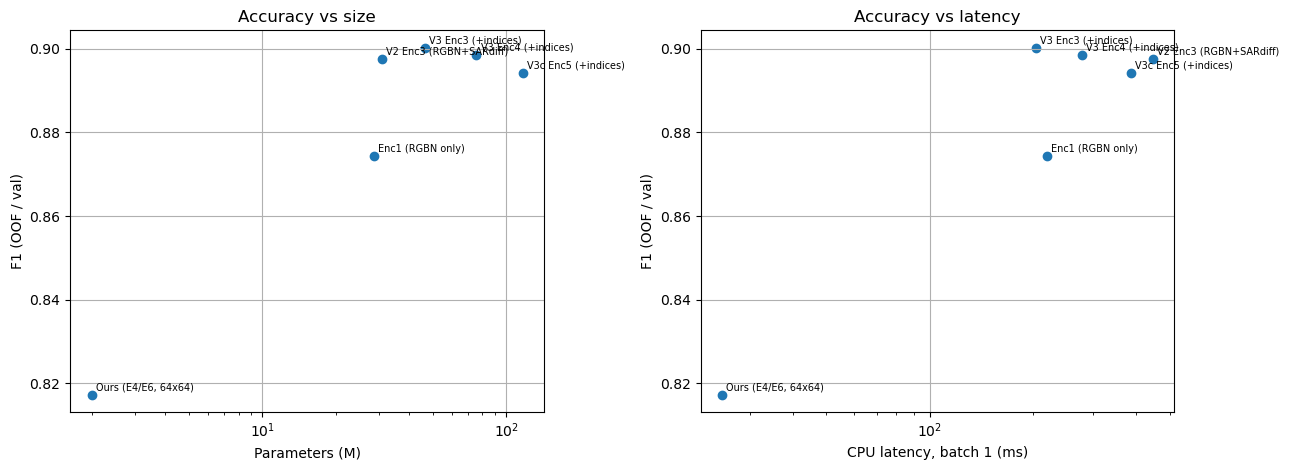

In [11]:
OUR_F1 = float(summarize_runs(e6_results)["best_val_f1"].max())     # or set by hand, e.g. 0.8092
table = add_f1_and_ratios(bench_df, OUR_F1)
display(table[["params_M", "GFLOPs", "cpu_ms_b1", "F1_oof", "F1_overall",
               "params_M_vs_ours", "GFLOPs_vs_ours", "cpu_ms_b1_vs_ours"]].round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for xcol, a, lab in [("params_M", ax[0], "Parameters (M)"), ("cpu_ms_b1", ax[1], "CPU latency, batch 1 (ms)")]:
    d = table.dropna(subset=["F1_oof"])
    a.scatter(d[xcol], d["F1_oof"])
    for n, r in d.iterrows():
        a.annotate(n.replace("Ref ", ""), (r[xcol], r["F1_oof"]), fontsize=7,
                   xytext=(3, 3), textcoords="offset points")
    a.set_xscale("log"); a.set_xlabel(lab); a.set_ylabel("F1 (OOF / val)"); a.grid(True)
ax[0].set_title("Accuracy vs size"); ax[1].set_title("Accuracy vs latency")
plt.tight_layout(); plt.show()

# Part 2 — roadmap after E6 (E7 → 5-fold CV)
All new functions live in `landslide_utils.py` (sections 9–16). Order: **E6d baseline → E7 global norm → E8 128 px → E9 BCE+SmoothF1 → E10 SAR-diff split → combine winners → fusion/TTA → distillation → 5-fold CV → final efficiency table.** Same restart rules: Run All, finished runs load from `results/`.

In [12]:
EPOCHS = 15
BASE = dict(aug=True, sched="cosine", lr=1e-3, epochs=EPOCHS)   # E6d recipe; edit if E6a/E6b beat it
# E7-E10 below each change ONE thing vs BASE. Use SEEDS = [42, 1, 2] before declaring any winner.

## E6d — baseline for everything below (cached if already run)

In [13]:
e6d = run_grid(data, {"E6d_aug_cos": dict(aug=True, sched="cosine", lr=1e-3)}, seeds=SEEDS)
display(summarize_runs(e6d).round(4))

[cached] E6d_aug_cos_seed42: loaded from disk (best val F1 = 0.8172 @ epoch 15)


,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E6d_aug_cos,0.8172,NaN,0.8106,0.0047,0.9746,15.0,1


## E7 — global normalisation
Per-image min-max (current) throws away absolute brightness/backscatter levels and lets one outlier pixel rescale a whole image. Global mean/std uses train-split statistics only (no leakage), clipped to ±5σ.

[cached] E7_gnorm_seed42: best val F1 = 0.8927 @ epoch 13


,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E6d_aug_cos,0.8172,NaN,0.8106,0.0047,0.9746,15.0,1
E7_gnorm,0.8927,NaN,0.8838,0.0083,0.9904,13.0,1


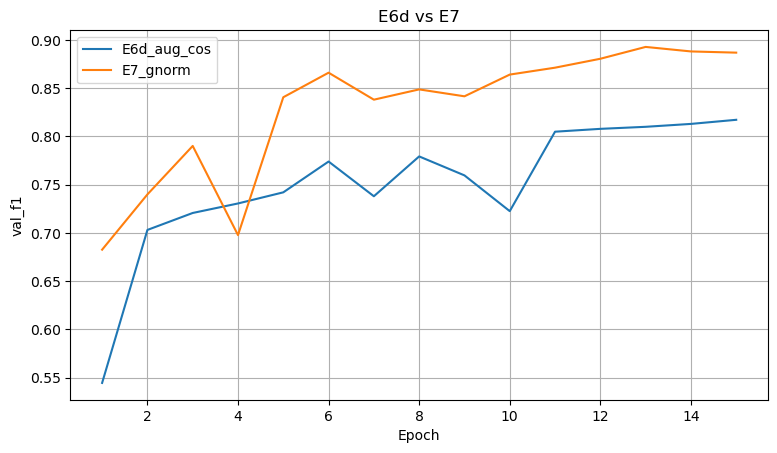

In [14]:
e7 = run_grid_ext(data, {"E7_gnorm": dict(norm="global")}, seeds=SEEDS, **BASE)
res = {**e6d, **e7}
display(summarize_runs(res).round(4)); plot_curves(res, "val_f1", "E6d vs E7")

## E8 — 128×128 input
Same network; the 64×64 patch is bilinearly upsampled **inside the model**, so the final feature map goes from 2×2 to 4×4. No new information, but better spatial resolution for the stride-32 backbone. Costs ≈4× FLOPs (still ≈0.09 GFLOPs). Measured in the benchmark section below.
Set `NORM` to `"global"` if E7 won.

[cached] E8_128_seed42: best val F1 = 0.8880 @ epoch 13


,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E6d_aug_cos,0.8172,NaN,0.8106,0.0047,0.9746,15.0,1
E7_gnorm,0.8927,NaN,0.8838,0.0083,0.9904,13.0,1
E8_128,0.8880,NaN,0.8830,0.0049,0.9907,13.0,1


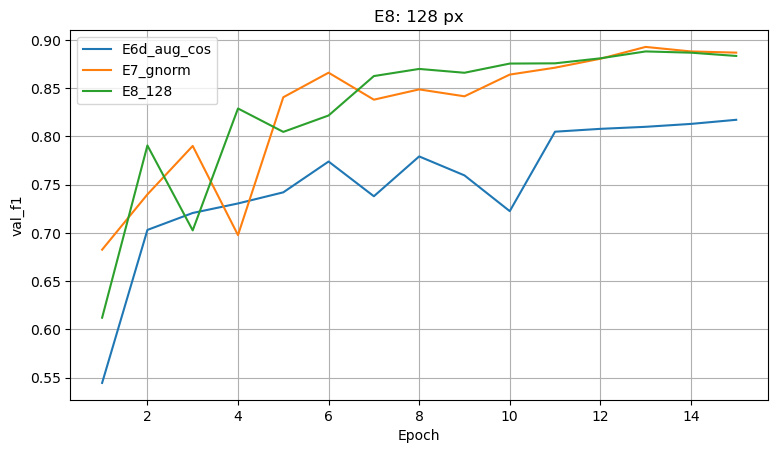

In [15]:
NORM = "global"                      # or "global" after looking at E7
e8 = run_grid_ext(data, {"E8_128": dict(norm=NORM, img_size=128)}, seeds=SEEDS, **BASE)
res = {**e6d, **e7, **e8}
display(summarize_runs(res).round(4)); plot_curves(res, "val_f1", "E8: 128 px")

## E9 — BCE + SmoothF1 loss
Adds `lam * (1 - soft-F1)` of the batch to the pos-weighted BCE. Directly optimises the metric you report; batch-level soft F1 is noisy at batch size 32, so keep `lam` moderate.

[cached] E9_sf1_0.5_seed42: best val F1 = 0.8681 @ epoch 15
[cached] E9_sf1_1.0_seed42: best val F1 = 0.8849 @ epoch 10


,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E6d_aug_cos,0.8172,NaN,0.8106,0.0047,0.9746,15.0,1
E7_gnorm,0.8927,NaN,0.8838,0.0083,0.9904,13.0,1
E8_128,0.8880,NaN,0.8830,0.0049,0.9907,13.0,1
E9_sf1_0.5,0.8681,NaN,0.8602,0.0066,0.9858,15.0,1
E9_sf1_1.0,0.8849,NaN,0.8773,0.0038,0.9886,10.0,1


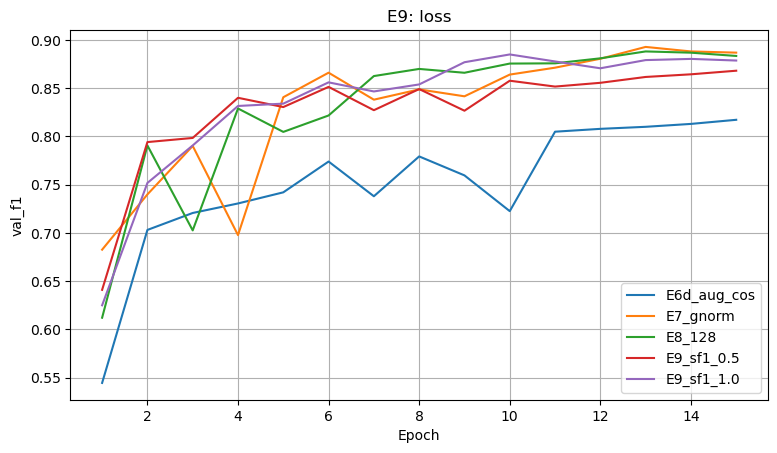

In [16]:
NORM = "global" 
e9 = run_grid_ext(data, {"E9_sf1_0.5": dict(norm=NORM, loss="bce_sf1", sf1_lam=0.5),
                         "E9_sf1_1.0": dict(norm=NORM, loss="bce_sf1", sf1_lam=1.0)},
                  seeds=SEEDS, **BASE)
res = {**e6d, **e7, **e8, **e9}
display(summarize_runs(res).round(4)); plot_curves(res, "val_f1", "E9: loss")

## E10 — SAR channel split (S2 + SAR-difference only)
The reference paper feeds `RGBN + SAR-diff` (raw channels 6,7,10,11). This keeps only those 4 of our 8 SAR channels in the S1 branch (fewer input channels, slightly fewer params).

[cached] E10_sardiff_seed42: best val F1 = 0.8647 @ epoch 15


,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E6d_aug_cos,0.8172,NaN,0.8106,0.0047,0.9746,15.0,1
E7_gnorm,0.8927,NaN,0.8838,0.0083,0.9904,13.0,1
E8_128,0.8880,NaN,0.8830,0.0049,0.9907,13.0,1
E9_sf1_0.5,0.8681,NaN,0.8602,0.0066,0.9858,15.0,1
E9_sf1_1.0,0.8849,NaN,0.8773,0.0038,0.9886,10.0,1
E10_sardiff,0.8647,NaN,0.8578,0.0057,0.9865,15.0,1


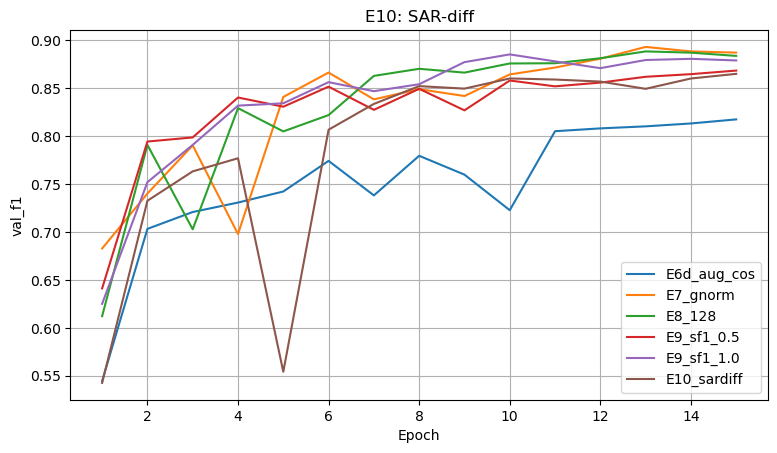

In [17]:
e10 = run_grid_ext(data, {"E10_sardiff": dict(norm=NORM, sar="diff")}, seeds=SEEDS, **BASE)
res = {**e6d, **e7, **e8, **e9, **e10}
display(summarize_runs(res).round(4)); plot_curves(res, "val_f1", "E10: SAR-diff")

## Final recipe — confirm E7 on 3 seeds
Evidence so far (single seed): global normalisation was the only change that beat run-to-run noise (E6d 0.817 → E7 0.893). E8 (128 px) and E9 (SoftF1 loss) were within noise, and E10 (SAR-diff only) was worse. **Final recipe = E6d training recipe + global normalisation, MobileNetV3-Small, 64 px, BCE.**

This cell runs both on seeds 42, 1, 2 (seed 42 is cached) and reports the gain as mean ± std over seeds. Expected time: about 4 new runs × 5 min.

[cached] E6d_aug_cos_seed42: loaded from disk (best val F1 = 0.8172 @ epoch 15)
[E6d_aug_cos_seed1] params=2,002,593 | {'tag': 'E6d_aug_cos', 'indices': [], 'aug': True, 'sched': 'cosine', 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 15, 'seed': 1, 'pretrained': True, 'batch_size': 32}
  [E6d_aug_cos_seed1] Epoch 01/15 | Train F1 0.4863 | Val F1 0.4129 | Val AUC 0.8443 | 80s
    -> new best, saved (F1 = 0.4129)
  [E6d_aug_cos_seed1] Epoch 02/15 | Train F1 0.6411 | Val F1 0.7128 | Val AUC 0.9397 | 21s
    -> new best, saved (F1 = 0.7128)
  [E6d_aug_cos_seed1] Epoch 03/15 | Train F1 0.6883 | Val F1 0.7069 | Val AUC 0.9303 | 21s
  [E6d_aug_cos_seed1] Epoch 04/15 | Train F1 0.7240 | Val F1 0.7563 | Val AUC 0.9641 | 22s
    -> new best, saved (F1 = 0.7563)
  [E6d_aug_cos_seed1] Epoch 05/15 | Train F1 0.7275 | Val F1 0.7575 | Val AUC 0.9544 | 24s
    -> new best, saved (F1 = 0.7575)
  [E6d_aug_cos_seed1] Epoch 06/15 | Train F1 0.7570 | Val F1 0.7340 | Val AUC 0.9561 | 22s
  [E6d_aug_cos_se

,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E6d_aug_cos,0.8295,0.0088,0.8236,0.0050,0.9772,14.0,3
E7_gnorm,0.8762,0.0117,0.8706,0.0046,0.9877,13.0,3


E7 - E6d, best F1   : +0.0466 ± 0.0250   per seed [0.033, 0.031, 0.076]
E7 - E6d, last-5 F1 : +0.0470 ± 0.0228   per seed [0.035, 0.033, 0.073]


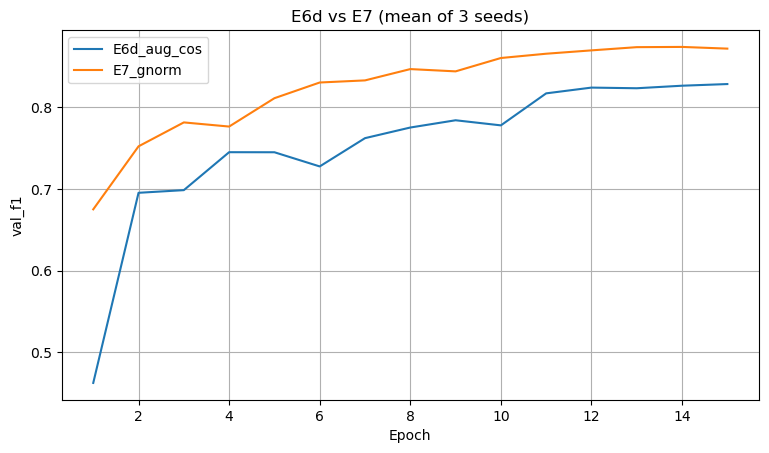

In [21]:
BASE  = dict(aug=True, sched="cosine", lr=1e-3, epochs=15)   # E6d training recipe
WIN   = dict(norm="global")                                  # the only change that beat noise
SEEDS = [42, 1, 2]

base  = run_grid(data, {"E6d_aug_cos": dict(aug=True, sched="cosine", lr=1e-3)}, seeds=SEEDS)  # per-image norm
final = run_grid_ext(data, {"E7_gnorm": WIN}, seeds=SEEDS, **BASE)                             # global norm
res3  = {**base, **final}

display(summarize_runs(res3).round(4))

rows = []
for tag, dfs in res3.items():
    for s, d in zip(SEEDS, dfs):
        rows.append({"run": tag, "seed": s,
                     "best_f1": d["val_f1"].max(),
                     "last5_mean_f1": d["val_f1"].iloc[-5:].mean()})
pv = pd.DataFrame(rows).pivot(index="seed", columns="run")
d_best  = pv["best_f1"]["E7_gnorm"] - pv["best_f1"]["E6d_aug_cos"]
d_last5 = pv["last5_mean_f1"]["E7_gnorm"] - pv["last5_mean_f1"]["E6d_aug_cos"]
print(f"E7 - E6d, best F1   : {d_best.mean():+.4f} ± {d_best.std():.4f}   per seed {d_best.round(3).tolist()}")
print(f"E7 - E6d, last-5 F1 : {d_last5.mean():+.4f} ± {d_last5.std():.4f}   per seed {d_last5.round(3).tolist()}")
plot_curves(res3, "val_f1", "E6d vs E7 (mean of 3 seeds)")

## Distillation (corrected)
The earlier teacher was a copy of the student (MobileNetV3-Small, 64 px, 2.0 M params), so that run was self-distillation. Here the teacher is a genuinely larger model (EfficientNet-B0 branches, 128 px input). **The student is only trained if the teacher is clearly better** (≥ +0.01 F1 above the E7 model); otherwise there is nothing to distil and this is reported as a skipped/negative result. Only the student counts in the efficiency claim.

In [22]:
KD_SEEDS = [42]          # teacher and student must use the same seed(s)
TEACHER  = dict(norm="global", backbone="effb0", img_size=128)

t = run_grid_ext(data, {"T_effb0_128": TEACHER}, seeds=KD_SEEDS, **BASE)   # old config differs -> retrains
t_f1 = summarize_runs(t).loc["T_effb0_128", "best_val_f1"]
s_f1 = summarize_runs(final).loc["E7_gnorm", "best_val_f1"]
print(f"teacher best F1 {t_f1:.4f}  vs  E7 (student-size) best F1 {s_f1:.4f}")

if t_f1 >= s_f1 + 0.01:
    STUDENT = dict(norm="global", distill_from="T_effb0_128", kd_alpha=0.5, kd_T=2.0)
    kd = run_grid_ext(data, {"S_kd_effb0": STUDENT}, seeds=KD_SEEDS, **BASE)   # NEW tag: old S_kd is cached
    display(summarize_runs({"E7_gnorm": final["E7_gnorm"][:1], **t, **kd}).round(4))
else:
    print("Teacher is not clearly stronger -> distillation not worth running. Report as skipped.")

[T_effb0_128_seed42] saved run differs or is incomplete -> re-running
[T_effb0_128_seed42] params=8,344,761 | {'tag': 'T_effb0_128', 'seed': 42, 'indices': [], 'aug': True, 'sched': 'cosine', 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 15, 'pretrained': True, 'batch_size': 32, 'norm': 'global', 'img_size': 128, 'sar': 'all', 'loss': 'bce', 'backbone': 'effb0', 'sf1_lam': 0.5, 'distill_from': None, 'kd_alpha': 0.5, 'kd_T': 2.0}
  [T_effb0_128_seed42] 01/15 | train F1 0.6118 | val F1 0.7156 | AUC 0.9180 | 57s
  [T_effb0_128_seed42] 02/15 | train F1 0.7226 | val F1 0.7828 | AUC 0.9736 | 56s
  [T_effb0_128_seed42] 03/15 | train F1 0.7725 | val F1 0.7523 | AUC 0.9795 | 56s
  [T_effb0_128_seed42] 04/15 | train F1 0.7882 | val F1 0.7882 | AUC 0.9815 | 55s
  [T_effb0_128_seed42] 05/15 | train F1 0.8002 | val F1 0.8525 | AUC 0.9810 | 55s
  [T_effb0_128_seed42] 06/15 | train F1 0.8090 | val F1 0.8250 | AUC 0.9797 | 55s
  [T_effb0_128_seed42] 07/15 | train F1 0.8279 | val F1 0.8868 | AUC 0.989

,best_val_f1,best_f1_std_over_seeds,last5_mean_f1,last5_std,auc_at_best,best_epoch,n_seeds
run,,,,,,,
E7_gnorm,0.8927,NaN,0.8838,0.0083,0.9904,13.0,1
T_effb0_128,0.9126,NaN,0.9034,0.0097,0.9916,13.0,1
S_kd_effb0,0.8915,NaN,0.8837,0.0017,0.9869,8.0,1


## 5-fold CV — the numbers to report
Same protocol as the reference paper: out-of-fold predictions on all of `Train.csv`, the **final epoch** of each fold (no best-epoch picking), threshold tuned on the OOF predictions. F1 at the fixed 0.5 threshold is shown too.

- `FINAL_ours` (seed 42) is cached from your earlier run.
- `FINAL_ours_s1` is a second CV run with a different seed. Averaging the two OOF probabilities shows what a 2-model lightweight ensemble gives (cost = 2× the single model, still tiny).

In [23]:
oof_a, folds_a = run_cv(data, "FINAL_ours",    n_splits=5, seed=42, **WIN, **BASE)   # cached, instant
oof_b, folds_b = run_cv(data, "FINAL_ours_s1", n_splits=5, seed=1,  **WIN, **BASE)   # 5 new trainings
assert (oof_a["ID"].values == oof_b["ID"].values).all()

y  = oof_a["label"].values
pa, pb = oof_a["oof_prob"].values, oof_b["oof_prob"].values
ths = np.arange(0.2, 0.81, 0.01)

res = {}
for name, p in {"seed 42 (single model)": pa,
                "seed 1 (single model)":  pb,
                "average of 2 seeds":     (pa + pb) / 2}.items():
    f1s = [f1_score(y, p >= t) for t in ths]
    res[name] = {"F1@0.5": f1_score(y, p >= 0.5), "best_thr": ths[int(np.argmax(f1s))],
                 "F1_tuned": max(f1s), "AUC": roc_auc_score(y, p)}
cv_tab = pd.DataFrame(res).T
display(cv_tab.round(4))
display(pd.concat({"seed42": folds_a, "seed1": folds_b}, axis=1).round(4))   # per-fold last-epoch F1

OURS_F1_1 = cv_tab.loc["seed 42 (single model)", "F1_tuned"]
OURS_F1_2 = cv_tab.loc["average of 2 seeds", "F1_tuned"]

[cached] FINAL_ours_cv5f0_seed42: best val F1 = 0.8510 @ epoch 15
[cached] FINAL_ours_cv5f1_seed42: best val F1 = 0.8555 @ epoch 12
[cached] FINAL_ours_cv5f2_seed42: best val F1 = 0.8658 @ epoch 11
[cached] FINAL_ours_cv5f3_seed42: best val F1 = 0.8609 @ epoch 11
[cached] FINAL_ours_cv5f4_seed42: best val F1 = 0.8827 @ epoch 15

[FINAL_ours] OOF F1@0.5 = 0.8580 | OOF F1 @ tuned thr 0.75 = 0.8656  (tuned thr = paper protocol)
[FINAL_ours_s1_cv5f0_seed1] params=2,002,593 | {'tag': 'FINAL_ours_s1_cv5f0', 'seed': 1, 'indices': [], 'aug': True, 'sched': 'cosine', 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 15, 'pretrained': True, 'batch_size': 32, 'norm': 'global', 'img_size': None, 'sar': 'all', 'loss': 'bce', 'backbone': 'mnv3s', 'sf1_lam': 0.5, 'distill_from': None, 'kd_alpha': 0.5, 'kd_T': 2.0}
  [FINAL_ours_s1_cv5f0_seed1] 01/15 | train F1 0.4969 | val F1 0.6561 | AUC 0.9034 | 21s
  [FINAL_ours_s1_cv5f0_seed1] 02/15 | train F1 0.7069 | val F1 0.7491 | AUC 0.9484 | 20s
  [FINAL_ours_

,F1@0.5,best_thr,F1_tuned,AUC
seed 42 (single model),0.8580,0.75,0.8656,0.9846
seed 1 (single model),0.8579,0.78,0.8695,0.9851
average of 2 seeds,0.8618,0.71,0.8746,0.9863


seed42           seed1        
     last_f1 best_f1 last_f1 best_f1
fold                                
0     0.8510  0.8510  0.8379  0.8464
1     0.8467  0.8555  0.8521  0.8577
2     0.8539  0.8658  0.8731  0.8814
3     0.8556  0.8609  0.8566  0.8571
4     0.8827  0.8827  0.8701  0.8701

## Efficiency table for the final model
- **Ours** is measured as the min of 5 median-of-30 CPU runs, with 4 threads and with 1 thread (edge-style).
- Reference models are loaded from the CSVs saved earlier by the robust benchmark (re-measured only if the files are missing).
- The reference ensemble is the sum of its 7 networks for one forward pass (no TTA, no folds), so its true cost is higher.
- The 128 px variant is included only to show what resolution would cost; it is not part of the final model.
- Run plugged in with other apps closed.

In [24]:
VARIANTS = {"Ours (E7 recipe, 64 px)": "E7_gnorm", "Ours 128 px (E8, not used)": "E8_128"}
ours4 = benchmark_variants(VARIANTS, cpu_threads=4, repeats=5)
ours1 = benchmark_variants(VARIANTS, cpu_threads=1, repeats=5)

def load_or_run(path, threads):
    if Path(path).exists():
        return pd.read_csv(path, index_col="model")
    df = robust_reference_benchmark(cpu_threads=threads, repeats=3)
    df.to_csv(path)
    return df

ref4 = load_or_run(RESULTS_DIR / "ref_bench_threads4.csv", 4)
ref1 = load_or_run(RESULTS_DIR / "ref_bench_threads1.csv", 1)

def ref_row(names):
    return dict(params_M=ref4.loc[names, "params_M"].sum(), GFLOPs=ref4.loc[names, "GFLOPs"].sum(),
                cpu_ms_4t=ref4.loc[names, "cpu_ms_min"].sum(), cpu_ms_1t=ref1.loc[names, "cpu_ms_min"].sum())

table = {n: {**ref_row([n]), "F1_oof": PAPER_F1[n][0]} for n in ref4.index}
table["Ref ensemble (7 NN, 1 pass)"] = {**ref_row(ENSEMBLE_MEMBERS), "F1_oof": 0.9216}   # paper Table 2, OOF

for n in ours4.index:
    table[n] = dict(params_M=ours4.loc[n, "params_M"], GFLOPs=ours4.loc[n, "GFLOPs"],
                    cpu_ms_4t=ours4.loc[n, "cpu_ms_min"], cpu_ms_1t=ours1.loc[n, "cpu_ms_min"], F1_oof=None)

ME = "Ours (E7 recipe, 64 px)"
table[ME]["F1_oof"] = OURS_F1_1
table["Ours x2 (2-seed ensemble)"] = {k: (v * 2 if k != "F1_oof" else OURS_F1_2) for k, v in table[ME].items()}

tab = pd.DataFrame(table).T.astype(float)
for c in ["params_M", "GFLOPs", "cpu_ms_4t", "cpu_ms_1t"]:
    tab[c + "_vs_ours"] = tab[c] / tab.loc[ME, c]
display(tab.round(3))

,params_M,GFLOPs,cpu_ms_4t,cpu_ms_1t,F1_oof,params_M_vs_ours,GFLOPs_vs_ours,cpu_ms_4t_vs_ours,cpu_ms_1t_vs_ours
Ref Enc1 (RGBN only),28.637,12.833,140.009,430.993,0.874,14.300,592.039,8.848,36.069
Ref Enc2 (SAR only),39.025,20.166,98.667,395.016,NaN,19.487,930.379,6.235,33.058
Ref V2 Enc3 (RGBN+SARdiff),31.045,15.361,100.752,368.999,0.898,15.502,708.705,6.367,30.880
Ref V3 Enc3 (+indices),46.566,23.109,153.146,570.357,0.900,23.253,1066.142,9.678,47.732
Ref V3 Enc4 (+indices),75.518,30.509,238.547,808.012,0.899,37.710,1407.542,15.075,67.620
Ref V3c Enc5 (+indices),116.791,59.151,332.274,1104.967,0.894,58.320,2728.961,20.999,92.472
"Ref ensemble (7 NN, 1 pass)",368.625,176.490,1164.146,4047.342,0.922,184.074,8142.475,73.570,338.711
"Ours (E7 recipe, 64 px)",2.003,0.022,15.824,11.949,0.866,1.000,1.000,1.000,1.000
"Ours 128 px (E8, not used)",2.003,0.080,19.744,11.508,NaN,1.000,3.705,1.248,0.963
Ours x2 (2-seed ensemble),4.005,0.043,31.647,23.898,0.875,2.000,2.000,2.000,2.000


## Final plot: F1 vs compute
Every point is a 5-fold OOF F1 with a tuned threshold (reference: paper Table 2; ours: the CV above), so all points are measured the same way. The F1 axis starts at 0.5 so the gap is not exaggerated.

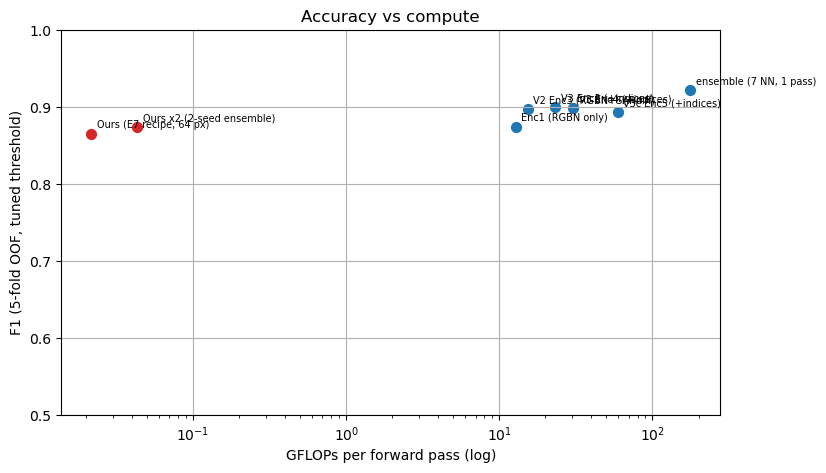

In [25]:
import matplotlib.pyplot as plt

d = tab.dropna(subset=["F1_oof"])
plt.figure(figsize=(8.5, 5))
for n, r in d.iterrows():
    is_ours = n.startswith("Ours")
    plt.scatter(r["GFLOPs"], r["F1_oof"], color="tab:red" if is_ours else "tab:blue", s=50)
    plt.annotate(n.replace("Ref ", ""), (r["GFLOPs"], r["F1_oof"]), fontsize=7,
                 xytext=(4, 4), textcoords="offset points")
plt.xscale("log"); plt.ylim(0.5, 1.0)
plt.xlabel("GFLOPs per forward pass (log)"); plt.ylabel("F1 (5-fold OOF, tuned threshold)")
plt.title("Accuracy vs compute"); plt.grid(True); plt.show()

## Final results and novelty analysis

### 1. Final accuracy (what we report)

All numbers are for the final recipe (global normalisation, flips + 90° rotations, 1-epoch warmup + cosine, ImageNet-pretrained dual MobileNetV3-Small, 64 × 64 input, class-weighted BCE) and use the same protocol as the reference paper: 5-fold out-of-fold (OOF) predictions over all 7,147 patches, final epoch of each fold, decision threshold tuned on the OOF predictions.

| Model | F1 @ 0.5 | F1 (tuned threshold) | Tuned thr. | AUC |
|---|---|---|---|---|
| Single model, seed 42 | 0.8580 | 0.8656 | 0.75 | 0.9846 |
| Single model, seed 1 | 0.8579 | 0.8695 | 0.78 | 0.9851 |
| **Single model (mean of 2 seeds)** | **0.858** | **0.868** | – | 0.985 |
| 2-seed probability average (2× cost) | 0.8618 | 0.8746 | 0.71 | 0.9863 |

**Headline number: OOF F1 = 0.868 for a single 2.0 M-parameter model.** The 2-model average (+0.007) is reported as an optional extra, not as the main result. Best-epoch single-split values (0.876 ± 0.012 over 3 seeds) are optimistic and are not used as the headline.

### 2. How we got there (controlled ablations)

| Step | Change | Val F1 | Evidence |
|---|---|---|---|
| E3 | dual MobileNetV3, random init | 0.629 | 1 seed |
| E4 | ImageNet initialisation | 0.774 | 1 seed |
| E5 | + NDVI / NDWI channels | 0.764 / 0.763 | 1 seed, no gain |
| E6 | augmentation + cosine schedule (E6d) | 0.830 ± 0.009 | 3 seeds |
| **E7** | **global normalisation** | **0.876 ± 0.012** | **3 seeds; +0.047 ± 0.025 over E6d, all seeds positive** |
| E8 / E9 / E10 | 128 px / SoftF1 loss / SAR-diff only | 0.888 / 0.885 / 0.865 | 1 seed, within noise of E7 |
| KD | distillation from a larger teacher | student = no gain | 1 seed (teacher 0.913 vs 0.893) |

Seed-to-seed standard deviation is about 0.012, so single-seed differences below roughly 0.02 are not resolvable. E8, E9, E10 and distillation are therefore reported as "no measurable difference".

### 3. Comparison with the reference paper (Nasios, arXiv:2604.05959)

| Model | Params | GFLOPs | CPU ms (4 thr / 1 thr) | OOF F1 |
|---|---|---|---|---|
| **Ours** | **2.0 M** | **0.022** | **15.8 / 11.9** | **0.868** |
| Ours, 2-seed average | 4.0 M | 0.043 | 31.6 / 23.9 | 0.875 |
| Ref Enc1 (RGBN only, MaxViT-tiny) | 28.6 M | 12.8 | 140 / 431 | 0.874 |
| Ref V3 Enc3 (best single, 3 streams) | 46.6 M | 23.1 | 153 / 570 | 0.900 |
| Ref ensemble (7 NN, 1 pass) | 368.6 M | 176.5 | 1164 / 4047 | 0.922 |

Relative to the best single reference model: **23× fewer parameters, ≈ 1,070× fewer FLOPs, 10× (4 threads) to 48× (1 thread) lower CPU latency**, at **−0.033 F1**. Relative to the optical-only reference model the F1 gap is ≈ 0.007. Relative to the full ensemble the gap is ≈ 0.054 at 184× fewer parameters.

Cost caveats: reference costs are for one forward pass of rebuilt (random-weight) networks, with no TTA and one fold model per network, so the real cost of the reference system is higher. Latency is PyTorch eager on one laptop CPU and is not FLOP-bound for our model (3.7× more FLOPs at 128 px costs only ≈ 1.25× latency), so deployment-runtime numbers (ONNX / TFLite, INT8) are still needed.

### 4. Novelty assessment

**What is not novel**
- Dual (per-modality) pretrained encoders with feature concatenation: the paper's own design, with more streams and larger transformer encoders.
- Flip/rotation augmentation, cosine schedule, F1-oriented loss, OOF threshold tuning and 5-fold CV: all used by the paper.
- Global (rather than per-image) input normalisation: standard practice, and the paper uses global standard/robust scaling. Our contribution here is only the measured effect on a lightweight model.
- Knowledge distillation and probability averaging: standard techniques, and neither gave a measurable gain here.

**What we contribute**
1. **Accuracy–efficiency benchmark on this dataset.** To our knowledge the paper reports no parameters, FLOPs, model size or memory (only epoch and inference times). We provide these for our model and for rebuilt versions of its architectures, measured on the same hardware.
2. **A different operating point.** A 2.0 M-parameter CNN that comes within ≈ 0.007 OOF F1 of the paper's optical-only transformer and within ≈ 0.033 of its best single multimodal model, at three orders of magnitude fewer FLOPs.
3. **A controlled ablation for lightweight models.** Pretraining (+0.145 F1, single seed), augmentation, schedule and normalisation (+0.047 over 3 seeds) are quantified one at a time. In this regime, spectral indices, 128 px upsampling, a SoftF1 loss term and distillation gave no measurable gain, which narrows the paper's recipe to what matters for a small model.
4. **Methodological findings.** Per-image min–max scaling (the starter-notebook default) costs ≈ 0.05 F1 relative to global scaling, and single-split best-epoch F1 overstates the 5-fold OOF F1 by ≈ 0.01–0.03.

**Prior work.** Lightweight multimodal landslide networks exist (for example the dual-stream attention network cited by the paper). Positioning against such work requires a literature check that has not yet been done.

### 5. Threats to validity
- Competition data without metadata: possible leakage between neighbouring patches in the same scene cannot be checked, which would inflate both our and the paper's OOF scores.
- Our folds, input size and training length differ from the paper's, so the F1 comparison is approximate. The tuned threshold is chosen on the same OOF predictions it is reported on (as in the paper).
- No evaluation on the hidden competition test set or on a second dataset.
- Several ablations are single-seed; efficiency numbers come from one machine and PyTorch eager mode.

### 6. Recommended positioning

> *We study how far a 2 M-parameter, pretrained dual-branch CNN can go on multimodal landslide classification. With global normalisation and light augmentation it reaches 0.868 OOF F1 on this benchmark, within 0.007 of the reference paper's optical-only transformer and 0.033 of its best single multimodal model, using 23× fewer parameters, ≈ 1,000× fewer FLOPs and 10–48× lower CPU latency. We do not claim state-of-the-art accuracy: the reference ensemble remains ≈ 0.05 F1 higher.*

### 7. What would strengthen the contribution
1. A genuinely new component: a lightweight cross-modal fusion block (gated / channel-attention / cross-attention), compared against plain concatenation at matched cost.
2. A real edge-deployment study: ONNX / TFLite with FP16 and INT8 on target hardware (for example Raspberry Pi or Jetson), reporting latency, memory and accuracy loss.
3. A model family (MobileNetV3-Small, MobileNetV3-Large, EfficientNet-B0) with 5-fold OOF F1 and measured cost, giving an accuracy–cost frontier.
4. 3-seed results for every ablation, a second dataset or the competition leaderboard score, and the literature check above.